In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
sentiment = pd.read_csv("fear_greed_index.csv")
trader = pd.read_csv("historical_data.csv")

In [7]:
print("Sentiment Dataset Shape:", sentiment.shape)
print("Trader Dataset Shape:", trader.shape)

Sentiment Dataset Shape: (2644, 4)
Trader Dataset Shape: (211224, 16)


In [8]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [9]:
trader.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [10]:
print("Sentiment Missing Values")
print(sentiment.isnull().sum())

print("\nTrader Missing Values")
print(trader.isnull().sum())

Sentiment Missing Values
timestamp         0
value             0
classification    0
date              0
dtype: int64

Trader Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [11]:
print("Sentiment Duplicates:", sentiment.duplicated().sum())

print("Trader Duplicates:", trader.duplicated().sum())

Sentiment Duplicates: 0
Trader Duplicates: 0


In [19]:

sentiment['date'].dtype


dtype('<M8[ns]')

In [15]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [17]:
print(sentiment['date'].dtype)

datetime64[ns]


In [18]:
trader['Timestamp IST'] = pd.to_datetime(trader['Timestamp IST'])

ValueError: time data "18-03-2025 12:50" doesn't match format "%m-%d-%Y %H:%M", at position 18. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [20]:
trader['Timestamp IST'] = pd.to_datetime(
    trader['Timestamp IST'],
    dayfirst=True
)

In [21]:
print(trader['Timestamp IST'].dtype)

datetime64[ns]


In [22]:
sentiment['Date'] = sentiment['date'].dt.date

In [23]:
trader['Date'] = trader['Timestamp IST'].dt.date

In [24]:
print(sentiment[['date', 'Date']].head())
print(trader[['Timestamp IST', 'Date']].head())

        date        Date
0 2018-02-01  2018-02-01
1 2018-02-02  2018-02-02
2 2018-02-03  2018-02-03
3 2018-02-04  2018-02-04
4 2018-02-05  2018-02-05
        Timestamp IST        Date
0 2024-12-02 22:50:00  2024-12-02
1 2024-12-02 22:50:00  2024-12-02
2 2024-12-02 22:50:00  2024-12-02
3 2024-12-02 22:50:00  2024-12-02
4 2024-12-02 22:50:00  2024-12-02


In [25]:
merged_df = pd.merge(
    trader,
    sentiment[['Date', 'classification']],
    on='Date',
    how='left'
)

In [26]:
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [27]:
merged_df.shape

(211224, 18)

In [28]:
merged_df['classification'].value_counts(dropna=False)

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
NaN                  6
Name: count, dtype: int64

In [29]:
daily_pnl = merged_df.groupby(['Account','Date'])['Closed PnL'].sum().reset_index()

In [30]:
daily_pnl.head()

,Account,Date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


In [31]:
merged_df['Win'] = merged_df['Closed PnL'] > 0

In [32]:
win_rate = merged_df.groupby('Account')['Win'].mean() * 100
win_rate = win_rate.reset_index()
win_rate.rename(columns={'Win':'Win Rate (%)'}, inplace=True)

win_rate.head()

,Account,Win Rate (%)
0,0x083384f897ee0f19899168e3b1bec365f52a9012,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,44.271978
2,0x271b280974205ca63b716753467d5a371de622ab,30.191651
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,43.858463
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,51.991355


In [33]:
avg_trade_size = merged_df.groupby('Account')['Size USD'].mean().reset_index()

In [34]:
avg_trade_size.rename(columns={'Size USD':'Average Trade Size'}, inplace=True)

avg_trade_size.head()

,Account,Average Trade Size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


In [36]:
trades_per_day = merged_df.groupby('Date').size().reset_index(name='Total Trades')

trades_per_day

,Date,Total Trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3
...,...,...
475,2025-04-27,337
476,2025-04-28,1379
477,2025-04-29,2243
478,2025-04-30,1113


In [39]:
long_short_ratio = merged_df[
    merged_df['Direction'].isin([
        'Open Long',
        'Close Long',
        'Open Short',
        'Close Short'
    ])
]

long_short_ratio['Direction'].value_counts()

Direction
Open Long      49895
Close Long     48678
Open Short     39741
Close Short    36013
Name: count, dtype: int64

In [ ]:
# PART B

In [40]:
pnl_by_sentiment = merged_df.groupby('classification')['Closed PnL'].agg(
    Total_Trades='count',
    Average_PnL='mean',
    Total_PnL='sum'
).reset_index()

pnl_by_sentiment

,classification,Total_Trades,Average_PnL,Total_PnL
0,Extreme Fear,21400,34.537862,7.391102e+05
1,Extreme Greed,39992,67.892861,2.715171e+06
2,Fear,61837,54.290400,3.357155e+06
3,Greed,50303,42.743559,2.150129e+06
4,Neutral,37686,34.307718,1.292921e+06


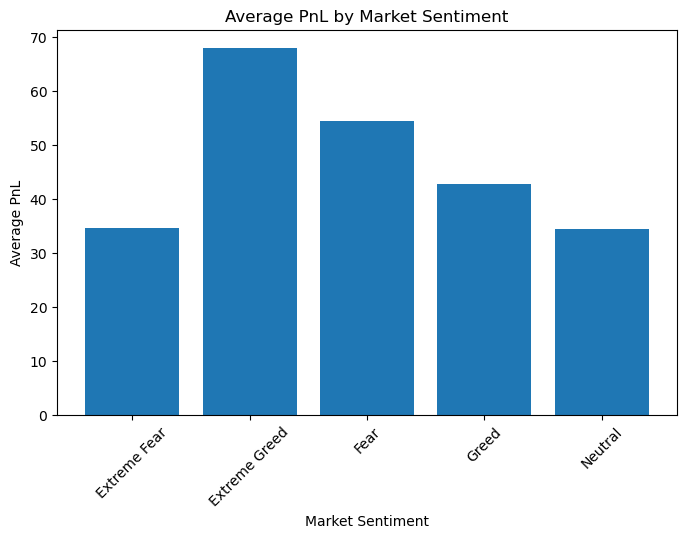

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    pnl_by_sentiment['classification'],
    pnl_by_sentiment['Average_PnL']
)

plt.title("Average PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL")

plt.xticks(rotation=45)

plt.show()

In [42]:
merged_df['Win'] = merged_df['Closed PnL'] > 0

win_rate_sentiment = merged_df.groupby('classification')['Win'].mean() * 100

win_rate_sentiment = win_rate_sentiment.reset_index()

win_rate_sentiment.rename(
    columns={'Win': 'Win Rate (%)'},
    inplace=True
)

win_rate_sentiment

,classification,Win Rate (%)
0,Extreme Fear,37.060748
1,Extreme Greed,46.494299
2,Fear,42.076750
3,Greed,38.482794
4,Neutral,39.699093


In [43]:
trade_frequency = merged_df.groupby('classification').size().reset_index(name='Total Trades')

trade_frequency

,classification,Total Trades
0,Extreme Fear,21400
1,Extreme Greed,39992
2,Fear,61837
3,Greed,50303
4,Neutral,37686


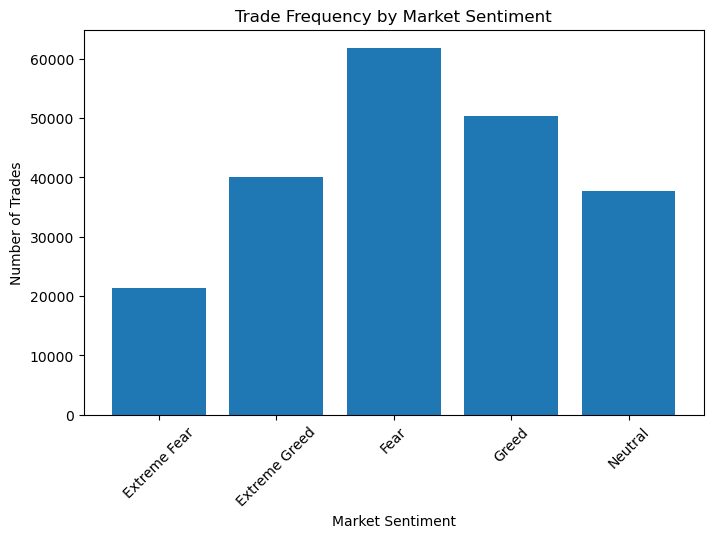

In [44]:
plt.figure(figsize=(8,5))

plt.bar(
    trade_frequency['classification'],
    trade_frequency['Total Trades']
)

plt.title("Trade Frequency by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=45)

plt.show()

In [45]:
avg_trade_sentiment = merged_df.groupby('classification')['Size USD'].mean().reset_index()

avg_trade_sentiment.rename(
    columns={'Size USD': 'Average Trade Size (USD)'},
    inplace=True
)

avg_trade_sentiment

,classification,Average Trade Size (USD)
0,Extreme Fear,5349.731843
1,Extreme Greed,3112.251565
2,Fear,7816.109931
3,Greed,5736.884375
4,Neutral,4782.732661


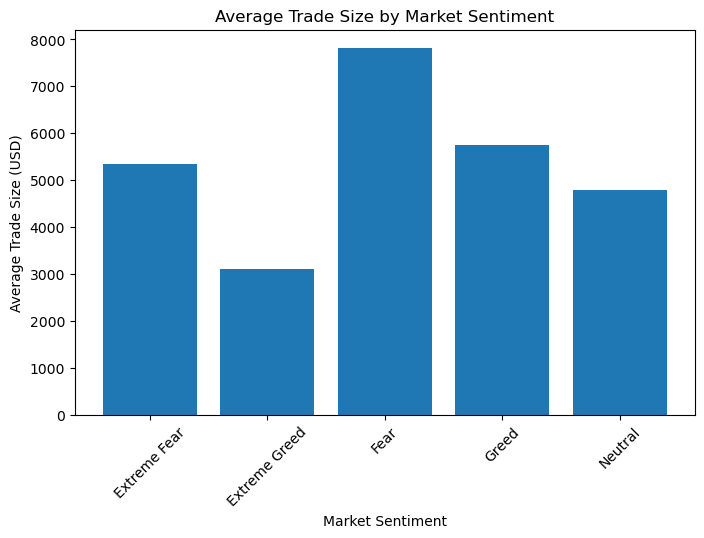

In [46]:
plt.figure(figsize=(8,5))

plt.bar(
    avg_trade_sentiment['classification'],
    avg_trade_sentiment['Average Trade Size (USD)']
)

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")

plt.xticks(rotation=45)

plt.show()

In [48]:
long_short = merged_df[
    merged_df['Direction'].isin([
        'Open Long',
        'Close Long',
        'Open Short',
        'Close Short'
    ])
].copy()

In [49]:
long_short['Position Type'] = long_short['Direction'].replace({
    'Open Long': 'Long',
    'Close Long': 'Long',
    'Open Short': 'Short',
    'Close Short': 'Short'
})

In [50]:
long_short_summary = pd.crosstab(
    long_short['classification'],
    long_short['Position Type']
)

long_short_summary

Position Type,Long,Short
classification,,
Extreme Fear,13246,6291
Extreme Greed,13486,14160
Fear,35084,20108
Greed,16542,22986
Neutral,20215,12203


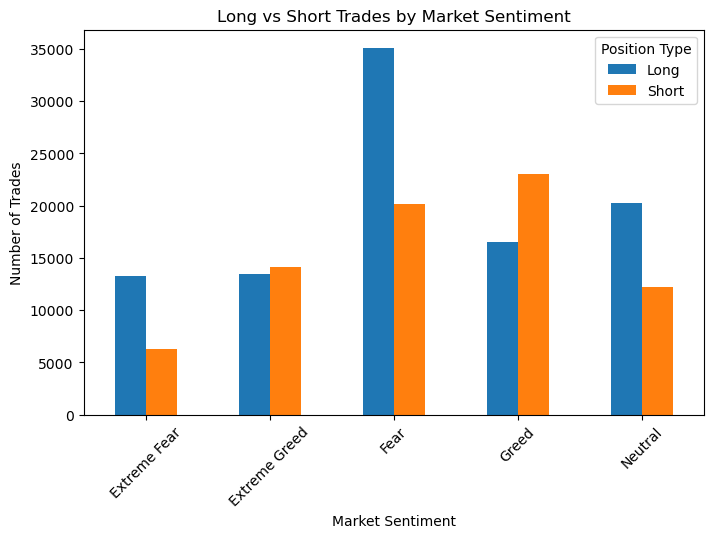

In [51]:
long_short_summary.plot(kind='bar', figsize=(8,5))

plt.title("Long vs Short Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=45)

plt.show()

In [52]:
trader_frequency = merged_df.groupby('Account').size().reset_index(name='Total Trades')

trader_frequency.head()

,Account,Total Trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280
2,0x271b280974205ca63b716753467d5a371de622ab,3809
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239


In [53]:
median_trades = trader_frequency['Total Trades'].median()

print(median_trades)

3699.0


In [54]:
trader_frequency['Trader Type'] = trader_frequency['Total Trades'].apply(
    lambda x: 'Frequent Trader' if x > median_trades else 'Infrequent Trader'
)

trader_frequency.head()

,Account,Total Trades,Trader Type
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,Frequent Trader
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,Frequent Trader
2,0x271b280974205ca63b716753467d5a371de622ab,3809,Frequent Trader
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,Frequent Trader
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,Infrequent Trader


In [55]:
trader_frequency['Trader Type'].value_counts()

Trader Type
Frequent Trader      16
Infrequent Trader    16
Name: count, dtype: int64

In [56]:
merged_df = merged_df.merge(
    trader_frequency[['Account', 'Trader Type']],
    on='Account',
    how='left'
)

In [57]:
segment_pnl = merged_df.groupby('Trader Type')['Closed PnL'].agg(
    Total_Trades='count',
    Average_PnL='mean',
    Total_PnL='sum'
).reset_index()

segment_pnl

,Trader Type,Total_Trades,Average_PnL,Total_PnL
0,Frequent Trader,186957,42.493421,7.944443e+06
1,Infrequent Trader,24267,96.943024,2.352516e+06


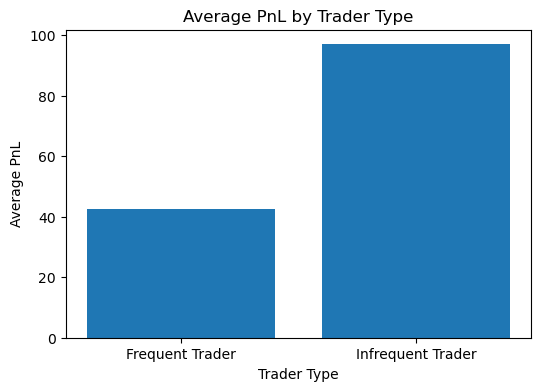

In [58]:
plt.figure(figsize=(6,4))

plt.bar(
    segment_pnl['Trader Type'],
    segment_pnl['Average_PnL']
)

plt.title("Average PnL by Trader Type")
plt.xlabel("Trader Type")
plt.ylabel("Average PnL")

plt.show()

In [59]:
win_rate['Trader Performance'] = win_rate['Win Rate (%)'].apply(
    lambda x: 'Consistent Winner' if x >= 50 else 'Inconsistent Trader'
)

win_rate.head()

,Account,Win Rate (%),Trader Performance
0,0x083384f897ee0f19899168e3b1bec365f52a9012,35.961236,Inconsistent Trader
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,44.271978,Inconsistent Trader
2,0x271b280974205ca63b716753467d5a371de622ab,30.191651,Inconsistent Trader
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,43.858463,Inconsistent Trader
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,51.991355,Consistent Winner


In [60]:
win_rate['Trader Performance'].value_counts()

Trader Performance
Inconsistent Trader    29
Consistent Winner       3
Name: count, dtype: int64

In [65]:
merged_df = merged_df.merge(
    win_rate[['Account', 'Trader Performance']],
    on='Account',
    how='left'
)

In [66]:
performance_summary = merged_df.groupby('Trader Performance')['Closed PnL'].agg(
    Total_Trades='count',
    Average_PnL='mean',
    Total_PnL='sum'
).reset_index()

performance_summary

,Trader Performance,Total_Trades,Average_PnL,Total_PnL
0,Consistent Winner,13549,45.804111,6.205999e+05
1,Inconsistent Trader,197675,48.950849,9.676359e+06


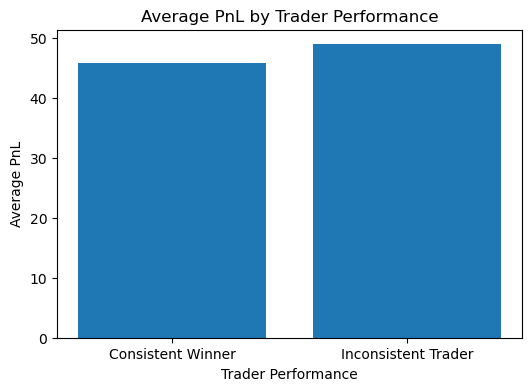

In [67]:
plt.figure(figsize=(6,4))

plt.bar(
    performance_summary['Trader Performance'],
    performance_summary['Average_PnL']
)

plt.title("Average PnL by Trader Performance")
plt.xlabel("Trader Performance")
plt.ylabel("Average PnL")

plt.show()